In [3]:
from sklearn.model_selection import cross_val_score
from sklearn import tree
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score  # metrics for manual model eval
import mlflow.pyfunc
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.feature_selection import mutual_info_classif
from pingouin import partial_corr

In [4]:
tsv1 = pd.read_csv(r'C:\Users\s434037\Desktop\Bachelor\data\labels.tsv', encoding='utf-8', sep='\t') #encoding and sep to read tsv correctly
tsv2 = pd.read_csv(r'C:\Users\s434037\Desktop\Bachelor\data\prostate_stats.tsv', encoding='utf-8', sep='\t') #encoding and sep to read tsv correctly

patient_data = pd.merge(tsv1, tsv2, left_on=['pseudo_id'], right_on=['pid'], how='inner') # merge both dataframes on pseudo_id and pid
patient_data.shape

(1204, 24)

In [ ]:
patient_data = pd.read_csv(r'C:\Users\s434037\Desktop\Bachelor\data\labels.tsv', encoding='utf-8', sep='\t') #encoding and sep to read tsv correctly

In [ ]:
patient_data = patient_data.dropna() # Drop rows with missing values for simplicity 
patient_data = patient_data.drop(columns=['pseudo_id', 'sex', 'pseudo_patid', 'pid', 'cx_px', 'cy_px', 'cz_px', 'cx', 'cy', 'cz']) # Drop patient_id as it's not a feature for prediction
patient_data = patient_data[patient_data.label != 2] # Remove rows with label 2 as these are not relevant for binary classification
patient_data = patient_data[patient_data.psa != 'NA'] # remove rows with no psa value till i find a better solution
patient_data = patient_data[patient_data.staging != 'primary'] # remove rows with primary staging till i find a better solution

patient_data['age'] = patient_data['age'].astype(float) # convert psa to float
patient_data['px'] = patient_data['px'].astype(float) # convert psa to float


In [78]:
patient_data['age'] = patient_data['age'].astype(float) # convert any ints to float to stop MLflow whining
patient_data['px'] = patient_data['px'].astype(float) 
patient_data['min'] = patient_data['min'].astype(float)
patient_data['max'] = patient_data['max'].astype(float)
patient_data['rmin'] = patient_data['rmax'].astype(float)
patient_data['mean'] = patient_data['mean'].astype(float)
patient_data['vol_pix'] = patient_data['vol_pix'].astype(float)
patient_data['vol_mm3'] = patient_data['vol_mm3'].astype(float)
patient_data['sd'] = patient_data['sd'].astype(float)

In [79]:
train_mask = patient_data['set'] == 'train' 
test_mask = patient_data['set'] == 'val'


In [80]:
X = pd.get_dummies(patient_data.drop("label", axis=1)) # dummies for categorical variables since forest doesn't handle them directly
X.index = patient_data.index
y = patient_data[["label"]].astype(int) # Keeping y as DataFrame for easier handling of set indicators


In [81]:
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
print(f"Train shape: {X_train.columns} {y_train.shape}") #double check proper set splits


Train shape: Index(['age', 'px', 'psa', 'min', 'max', 'rmin', 'rmax', 'vol_pix', 'vol_mm3',
       'mean', 'sd', 'staging_re', 'set_train', 'set_val'],
      dtype='object') (706, 1)


In [82]:
X_train = X_train.drop(columns=['set_train', 'set_val'], errors= 'ignore') # Drop the set indicator columns
X_test = X_test.drop(columns=['set_train', 'set_val'], errors = 'ignore')

print(X_test.shape, X_train.shape)

(166, 12) (706, 12)


In [83]:
y_test = np.array(y_test).astype(int) # Convert y_test to a NumPy array of strings
y_train = np.array(y_train).astype(int) # Convert y_train to a NumPy array of strings

y_test = y_test.squeeze()
y_train = y_train.squeeze()

In [84]:
y_test.shape

(166,)

In [85]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

if X_train.empty or X_test.empty:
    raise ValueError("One of the datasets (train/test) is empty!")

Unique labels in y_train: [0 1]
Unique labels in y_test: [0 1]


In [ ]:
if len(X_train) != len(y_train):
    print("Mismatch between X_train and y_train lengths!")
    raise SystemExit()
if len(X_test) != len(y_test):
    print("Mismatch between X_test and y_test lengths!")
    raise SystemExit()

In [87]:
forest_params = {
    "min_weight_fraction_leaf": 0.1,
    "n_estimators": 30,
}

In [19]:
param_grid = {
    'min_samples_split': [2, 3, 4],
    'min_weight_fraction_leaf': [0.1],
    'min_impurity_decrease': [0.0, 0.01, 0.1],
    'max_leaf_nodes': [None, 10, 20],
    
}

In [20]:
rf_classifier = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1', error_score='raise')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
model = RandomForestClassifier(**best_params)
model = model.fit(X_train, y_train)

In [21]:
model = RandomForestClassifier(**forest_params) # Initialize the random forest with specified parameters
model = model.fit(X_train, y_train)


NameError: name 'forest_params' is not defined

In [98]:
X_reduced = X_train.drop(columns=['psa', 'age', 'min', 'vol_pix', 'rmax', 'rmin', 'mean']) # select features based on prior feature importance analysis
if len(X_train) != len(y_train):
    print("Mismatch between X_train and y_train lengths!")
    raise SystemExit()
if len(X_reduced) != len(y_test):
    print("Mismatch between X_reduced and y_test lengths!")
    raise SystemExit()

Mismatch between X_reduced and y_test lengths!


SystemExit: 

c:\Users\s434037\AppData\Local\miniforge3\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [89]:
params = {
            #'min_weight_fraction_leaf': 0.1,
            'random_state': 42,
            'scale_pos_weight': 0.3,
            'n_estimators': 300,
            'max_depth': 4,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'eval_metric': 'logloss',
            'objective': 'binary:logistic',
        }


In [100]:

modelA = XGBClassifier(**params).fit(X_train, y_train)
modelB = XGBClassifier(**params).fit(X_reduced, y_train)

In [104]:
X_test_reduced = X_test.drop(columns=['psa', 'age', 'min', 'vol_pix', 'rmax', 'rmin', 'mean'])

In [105]:
scores_full = cross_val_score(modelA, X_test, y_test, scoring='roc_auc', cv=5)
scores_reduced = cross_val_score(modelB, X_test_reduced, y_test, scoring='roc_auc', cv=5)
print(scores_full.mean(), scores_reduced.mean())

0.7835454019664546 0.8044013880855985


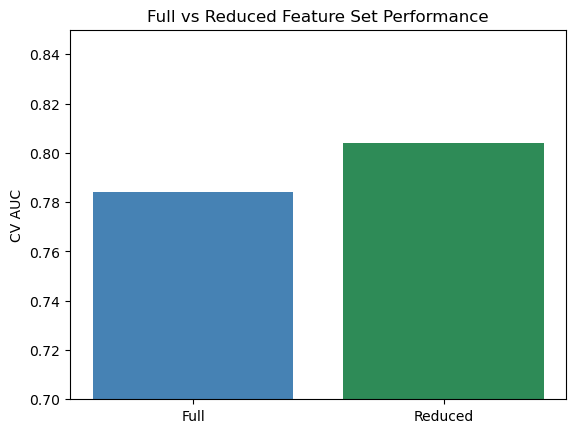

In [106]:
plt.bar(['Full', 'Reduced'], [0.784, 0.804], color=['steelblue', 'seagreen'])
plt.ylabel("CV AUC")
plt.title("Full vs Reduced Feature Set Performance")
plt.ylim(0.7, 0.85)
plt.show()

In [ ]:
model_path = r"C:/Users/s434037/Desktop/Bachelor/projects/mlruns/480120777834226073/models/m-fa63154747d64c93ab3f4c76ace550db/artifacts"
model = mlflow.sklearn.load_model (model_path)

In [14]:
model_uri = f"models:/randomForestV1/version-1"
model = mlflow.sklearn.load_model(model_uri)

MlflowException: Invalid Model Version stage: version-1. Value must be one of None, Staging, Production, Archived.

In [33]:
patient_data.drop(columns=['set', 'staging'], inplace=True)

In [28]:
partial_corr(
    data=patient_data,
    x='min',
    y='label',
    covar=['mean', 'psa', 'age', 'px','rmin', 'max', 'rmax', 'vol_mm3', 'sd', 'vol_pix'],
    method='spearman'
)

,n,r,CI95%,p-val
spearman,872,0.012613,"[-0.05, 0.08]",0.711533


In [35]:
X = patient_data.drop(columns=['label'])
y = patient_data['label']

mi = mutual_info_classif(X, y, discrete_features=False)

mi_df = pd.DataFrame({
    'feature': X.columns,
    'mutual_information': mi
}).sort_values('mutual_information', ascending=False)
mi_df

,feature,mutual_information
4,max,0.194457
5,rmin,0.157422
6,rmax,0.155125
1,px,0.114014
10,sd,0.093085
8,vol_mm3,0.071485
3,min,0.060634
7,vol_pix,0.059580
9,mean,0.054890
0,age,0.022511


In [32]:
X.dtypes


age        float64
staging     object
px         float64
psa        float64
set         object
min        float64
max        float64
rmin       float64
rmax       float64
vol_pix    float64
vol_mm3    float64
mean       float64
sd         float64
dtype: object

In [22]:
eval_data= X_test.copy()
eval_data['label']= y_test #create eval data for flow evaluation

In [ ]:
y_pred = model.predict(X_test) # Make predictions on the test set
metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"), 
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "f1_score": f1_score(y_test, y_pred, average='weighted'),
    }

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.89      0.81        98
           1       0.78      0.57      0.66        68

    accuracy                           0.76       166
   macro avg       0.77      0.73      0.74       166
weighted avg       0.76      0.76      0.75       166



In [24]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")
print(f"Test score: {best_score:.3f}")

Best parameters: {'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.1}
Best cross-validation score: 0.718
Test score: 0.718


In [25]:
result = mlflow.models.evaluate(
    model_path,
    eval_data,
    targets="label",
    model_type="classifier",
)

# Access metrics
print(f"Precision: {result.metrics['precision_score']:.3f}")
print(f"Recall: {result.metrics['recall_score']:.3f}")
print(f"F1 Score: {result.metrics['f1_score']:.3f}")
print(f"ROC AUC: {result.metrics['roc_auc']:.3f}")

NameError: name 'model_path' is not defined